# Airbnb Price Prediction
#### By Damiru Vidunitha Wanniarachchi (S4137361)

### How to Run:
1. Install required libraries
2. Place `train_data.csv` and `test_data.csv` in `dataset` folder in the same directory
3. Run all cells sequencially

## 1.0 Imports and Setup

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn scipy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2.0 Dataset

Loading the training and test datasets provided on Canvas. The training dataset includes the target variable `price` whereas the test dataset does not.

### 2.1 Load Dataset

In [3]:
# dataframes
df_tr = pd.read_csv('dataset/train_data.csv')
df_te = pd.read_csv('dataset/test_data.csv')

### 2.2 Understanding the data

#### The first few rows of the training data.

In [4]:
df_tr.head()

,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Kingston,Australia,-38.022565,145.098937,Entire home/apt,5,1.0,2.0,4.0,111,3,28,94.0,t,1
1,f,Yarra,Australia,-37.782125,144.988079,Entire home/apt,3,1.0,1.0,1.0,80,1,59,93.0,t,1
2,t,Port Phillip,Australia,-37.853710,144.981529,Entire home/apt,4,1.0,1.0,2.0,150,2,14,100.0,f,1
3,f,Glen Eira,Australia,-37.876393,145.036635,Entire home/apt,2,1.0,1.0,1.0,125,1,39,97.0,f,55
4,f,Melbourne,Australia,-37.810398,144.950113,Entire home/apt,3,1.0,1.0,2.0,79,3,7,97.0,t,1


In [5]:
df_tr.info()

<class 'pandas.DataFrame'>
RangeIndex: 8586 entries, 0 to 8585
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_is_superhost               8586 non-null   str    
 1   city                            8586 non-null   str    
 2   country                         8586 non-null   str    
 3   latitude                        8586 non-null   float64
 4   longitude                       8586 non-null   float64
 5   room_type                       8586 non-null   str    
 6   accommodates                    8586 non-null   int64  
 7   bathrooms                       8586 non-null   float64
 8   bedrooms                        8586 non-null   float64
 9   beds                            8586 non-null   float64
 10  price                           8586 non-null   int64  
 11  minimum_nights                  8586 non-null   int64  
 12  number_of_reviews               8586 non-null

In [6]:
df_tr.describe()

,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,calculated_host_listings_count
count,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000
mean,-37.825074,145.009374,3.559865,1.282320,1.533077,2.036222,139.771372,3.158747,27.946657,94.176101,7.427324
std,0.065145,0.130473,2.225801,0.557906,0.916369,1.544967,123.293376,20.788007,42.409812,8.471527,15.438001
min,-38.224427,144.531993,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,20.000000,1.000000
25%,-37.849202,144.957065,2.000000,1.000000,1.000000,1.000000,71.000000,1.000000,3.000000,92.000000,1.000000
50%,-37.816460,144.977004,3.000000,1.000000,1.000000,2.000000,115.000000,2.000000,11.000000,97.000000,1.000000
75%,-37.802849,145.008316,4.000000,1.500000,2.000000,2.000000,162.750000,3.000000,33.000000,100.000000,5.000000
max,-37.491059,145.760250,16.000000,9.000000,10.000000,18.000000,3000.000000,1000.000000,479.000000,100.000000,98.000000


The dataset contains 8586 listing and 16 features. As it is indicated above, the dataset has non-null values for all the entries for all the columns, so **no missing data** in present.

Some numerical features such as `Price`, `minimum_nights`indicate varying ranges and distributions.
For example, `Price` has a *mean* of ~139.77 whereas it ranges from a minimum of 0 to 3000 showing a **right-skewed distribution**. This suggests that there's a small number of high-priced house listings that may influence the overall distribution.

## 2.3 Data Preprocessing

Machine learning models cannot work directly with strings. Therefore, we create **one-hot endodings** of *string features* (non-ordial categorical). As for *binary features* (Yes/No), we create **binary encodings** (0/1).

For *numerical features*, applying one-hot encodings to features like `Price`, `beds`, `minimum_nights` where the *magnitude* matters, would lose its inherent meaning. Therefore, we keep the *numerical features* **untouched**.

#### Feature Types

In [7]:
# binary features for binary encoding
ft_bin = ['host_is_superhost', 'instant_bookable']

# categorical features for one-hot encoding
ft_cat = ['city', 'country', 'room_type']

# Numerical features (excluding price)
ft_num = ['latitude', 'longitude', 'accommodates', 'bathrooms', 
                'bedrooms', 'beds', 'minimum_nights',
                'number_of_reviews', 'review_scores_rating', 
                'calculated_host_listings_count']

#### Preprocess Training & Test Data

In [8]:
# binary encoding
for ft in ft_bin:
    df_tr[ft] = df_tr[ft].map({'t':1, 'f':0})
    df_te[ft] = df_te[ft].map({'t':1, 'f':0})

**!Note:** `drop_first=True` (below) drops the first feature to avoid multicolinearity. Multicolinearity could make *Regression* models unstable.

In [9]:
# one-hot encoding
## drop_first: drops one category to avoid multicolinearity
df_tr = pd.get_dummies(df_tr, columns=ft_cat, drop_first=True)
df_te = pd.get_dummies(df_te, columns=ft_cat, drop_first=True)

In [10]:
# ML ready dataframe
df_tr.head()

,host_is_superhost,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,...,city_Nillumbik,city_Port Phillip,city_Stonnington,city_Whitehorse,city_Whittlesea,city_Wyndham,city_Yarra,city_Yarra Ranges,room_type_Private room,room_type_Shared room
0,0,-38.022565,145.098937,5,1.0,2.0,4.0,111,3,28,...,False,False,False,False,False,False,False,False,False,False
1,0,-37.782125,144.988079,3,1.0,1.0,1.0,80,1,59,...,False,False,False,False,False,False,True,False,False,False
2,1,-37.853710,144.981529,4,1.0,1.0,2.0,150,2,14,...,False,True,False,False,False,False,False,False,False,False
3,0,-37.876393,145.036635,2,1.0,1.0,1.0,125,1,39,...,False,False,False,False,False,False,False,False,False,False
4,0,-37.810398,144.950113,3,1.0,1.0,2.0,79,3,7,...,False,False,False,False,False,False,False,False,False,False


#### Align train and test dataframes (columns)

In [11]:
# align test dataframe to train dataframe
df_te = df_te.reindex(columns=df_tr.columns, fill_value=0)

In [12]:
df_te.head()

,host_is_superhost,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,...,city_Nillumbik,city_Port Phillip,city_Stonnington,city_Whitehorse,city_Whittlesea,city_Wyndham,city_Yarra,city_Yarra Ranges,room_type_Private room,room_type_Shared room
0,0,-37.766505,144.980736,2,1.0,1.0,1.0,0,3,108,...,False,False,False,False,False,False,False,False,True,False
1,1,-37.859755,144.977369,3,1.0,1.0,2.0,0,3,15,...,False,True,False,False,False,False,False,False,False,False
2,0,-37.864530,144.992238,2,1.0,1.0,2.0,0,1,63,...,False,True,False,False,False,False,False,False,True,False
3,0,-37.697294,145.000816,2,1.0,1.0,1.0,0,7,159,...,False,False,False,False,False,False,False,False,True,False
4,0,-37.810267,144.985920,2,1.0,1.0,1.0,0,1,3,...,False,False,False,False,False,False,False,False,True,False


## 2.4 Exploratory Data Analysis

#### Distribution of Price

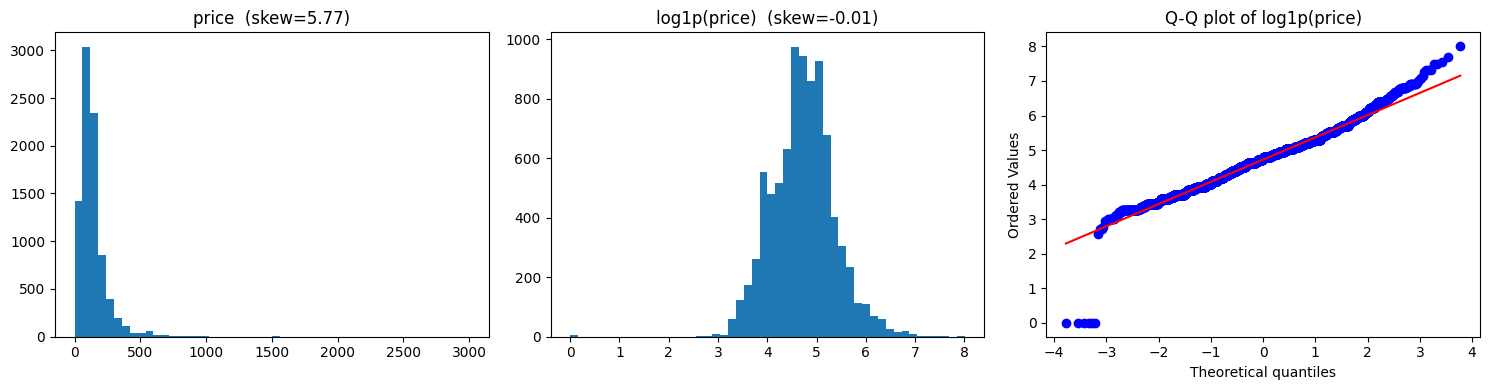

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# raw price
axes[0].hist(df_tr['price'], bins=50)
axes[0].set_title(f'price  (skew={df_tr["price"].skew():.2f})')

# log price
price_log = np.log1p(df_tr['price']) # log1p: safer handling zeros
axes[1].hist(price_log, bins=50)
axes[1].set_title(f'log1p(price)  (skew={price_log.skew():.2f})')

# q-q plot
stats.probplot(price_log, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q plot of log1p(price)')

plt.tight_layout()

As we deducted before, the *raw price distribution* is **strongly right-skewed (skweness = $5.77$)** where the vast majority of the prices lie within the **$0-500$** range indicating that most listings are relatively affordable with a small number of high-priced *outliers.* This *violates homoscedasticity* of linear regression (**heteroscedasticity**) where error variances across data are unequal, making the high-priced listings *disproportionately influencial*. However, after applying *log1p* the skewness has been **reduced to $-0.01$** producing a more symmetric distribution suitable for linear models.

The *Q-Q plot* showcases the *quantiles of the transformed data vs a normal distribution* incidcating that the transformed data follows a normal distribution with *minor deviation* on the tail consistent with the few extreme-priced listings remaining in the data, further *strengthening the transformation*.

#### Missing values

In [14]:
print(df_tr.isnull().sum()[df_tr.isnull().sum() > 0])

Series([], dtype: int64)


As deducted before, the above affirms that there're **no missing values present**.

#### Numerical Features vs. Log(Price)

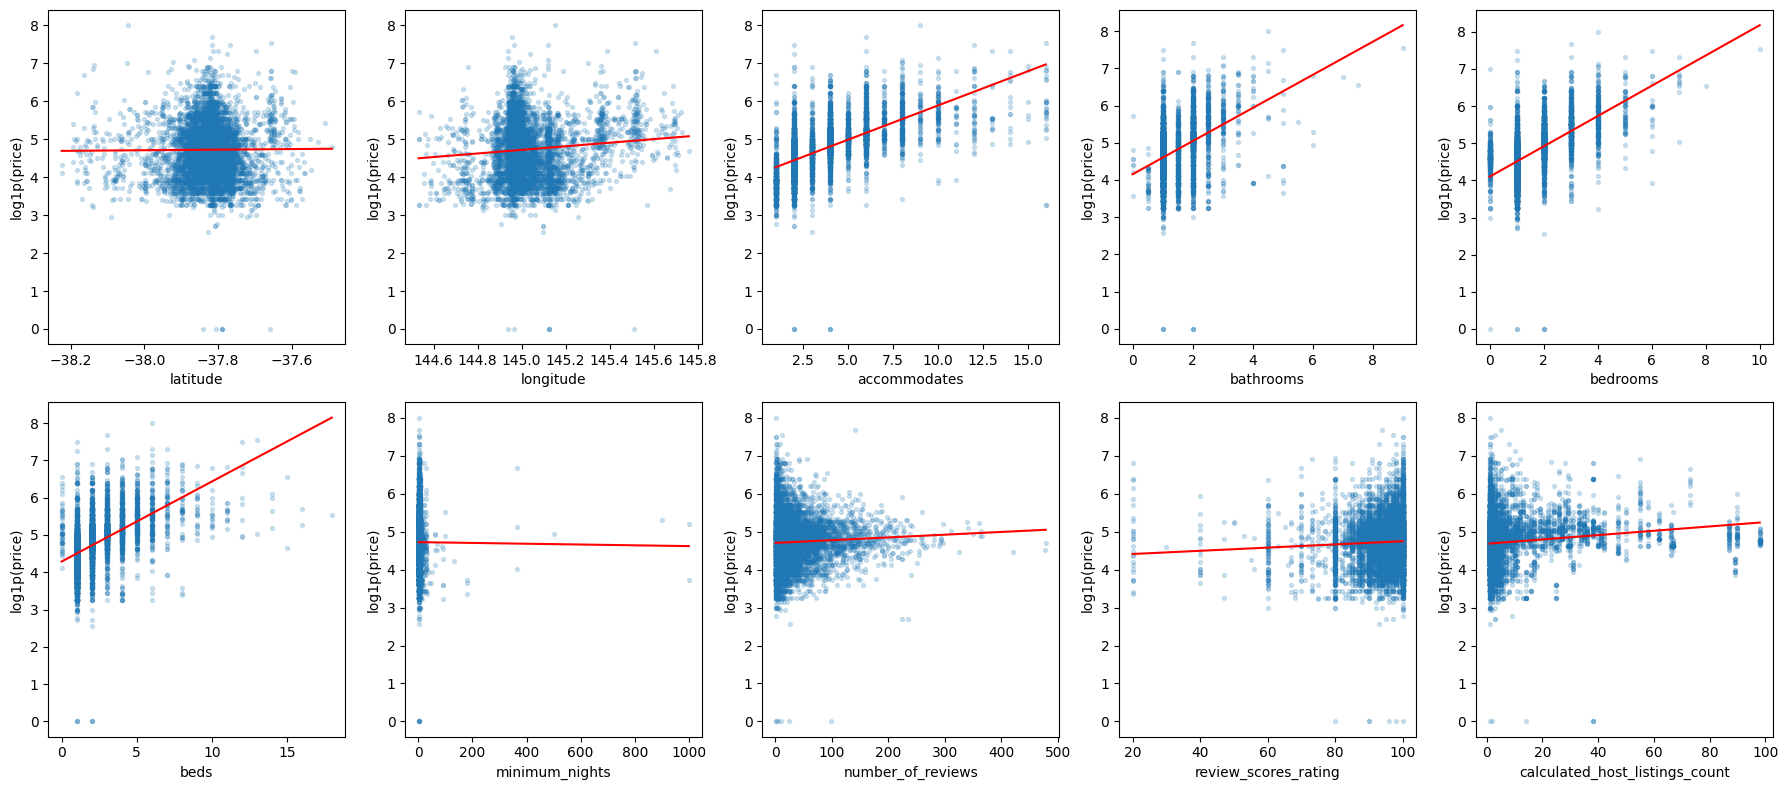

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, feat in zip(axes.flatten(), ft_num):
    ax.scatter(df_tr[feat], np.log1p(df_tr['price']), alpha=0.2, s=8)
    ax.set_xlabel(feat)
    ax.set_ylabel('log1p(price)')
    # regression line to see linear trend
    m, b = np.polyfit(df_tr[feat].fillna(df_tr[feat].median()), np.log1p(df_tr['price']), 1)
    x_line = np.linspace(df_tr[feat].min(), df_tr[feat].max(), 100)
    ax.plot(x_line, m*x_line + b, 'r-', linewidth=1.5)
plt.tight_layout()

Features such as `accommodates`, `bathrooms`, `bedrooms`, and `beds` show *positive linear trends* with *log1p(price)*, indicating that larger, better-equipped listings tend to have higher prices.

Other numerical features showcase weaker relationships:

- `latitude` and `longitude` are mostly flat, with data clustered to the middle of the ranges which are *melbourne inner suburbs* making raw coordinates poor linear predictors.

- `minimum_nights` is *heavily right-skewed*, with most listings are near zero, showing small linear trend.
- `number_of_reviews` and `calculated_host_listings_count` also show *right-skewed distribution* eventhough not as heavy with *linear trends*.
- `review_scores_rating` shows a *left-skewed distribution* indicating most listings got higher review ratings which limits discriminative power.

Overall, the *log transformation* stablizes *residual variance* across prices (*homoscedasticity*) and enhances existing *linear trends*, making data more *suitable* for the models. In short, `log1p(price)` is a better target for *regression models*.

#### Categorical Features vs. Log(Price)

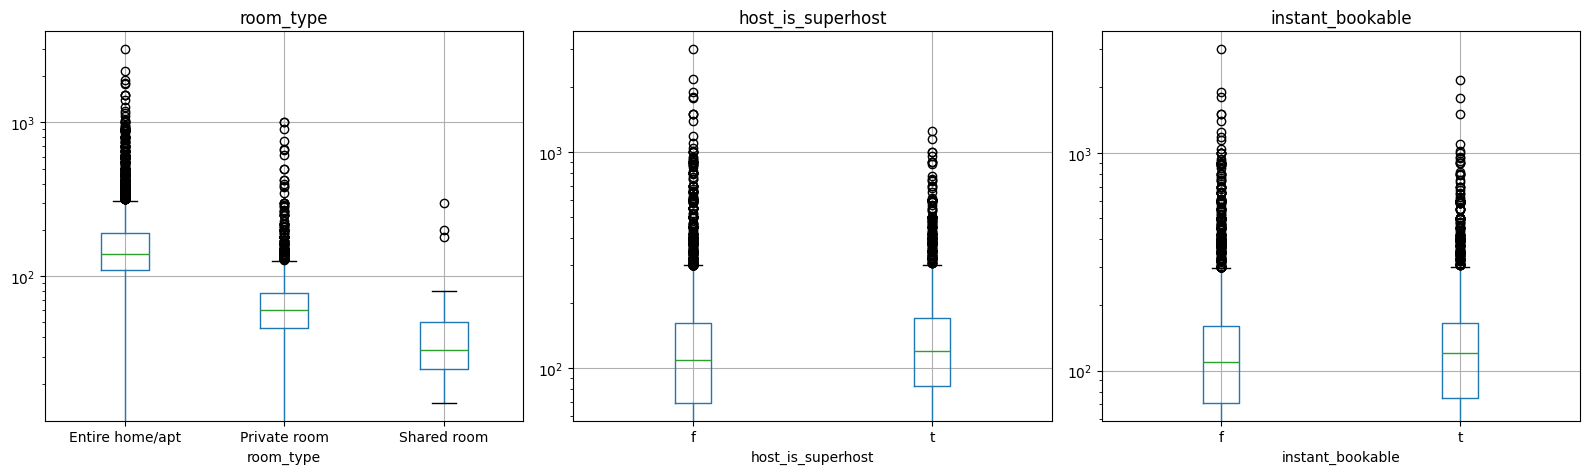

In [16]:
# load training data again to access original data
df_tr_original = pd.read_csv('dataset/train_data.csv')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, ['room_type', 'host_is_superhost', 'instant_bookable']):
    df_tr_original.boxplot(column='price', by=feat, ax=ax)
    ax.set_yscale('log')  # log scale on y so you can actually see the boxes
    ax.set_title(feat)
plt.suptitle('')
plt.tight_layout()

`room_type` feature shows strong grouping across all three types, with differing medians. This feature is *one-hot encoded* and is expected to have *high coeficient magnitude* in all models. Most of the *outliers (high-priced listings)* are very concentrated within the 'Entire home/apt' and 'Private room' agreeing to the nature of luxury rentals.

`host_is_superhost` however, shows minimal differetiation of prices with median prices being nearly identical across both types. This suggests that `host_is_superhost` does not command a higher price in the dataset. Therefore, this feature may contribute *less* to model performance. As for *outlier density and range* of this feature, moderate difference is present, but not significant enough to support that `host_is_superhost` feature drive the price of listings.

`instant_bookable` too shows minimal differentiation of prices with almost identical medians. The *outlier density* of the types are nearly identical suggesting that this feature does not have considerable influence on prices of listings as well.

#### Correlation Heatmap

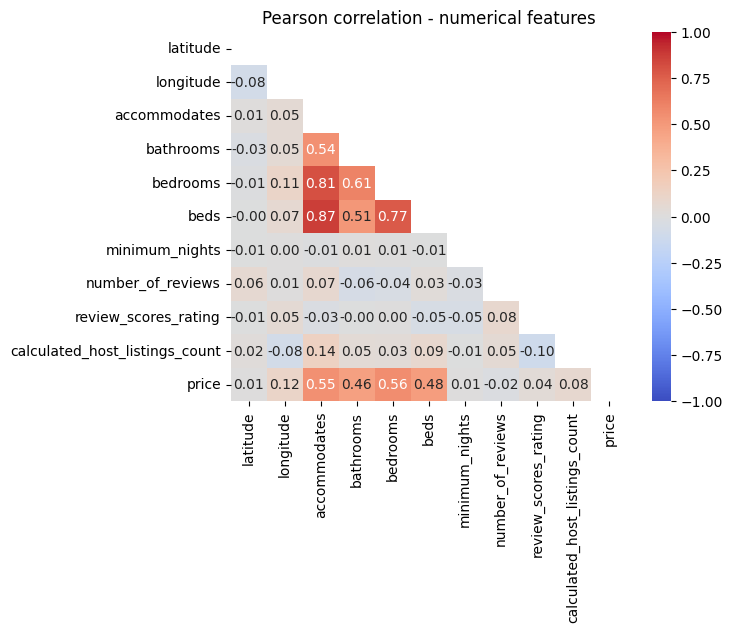

In [17]:
corr = df_tr[ft_num + ['price']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle only

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1)
plt.title('Pearson correlation - numerical features')
plt.show()

The pearson correlation heatmap above, shows that features related to the *physical capacity of Airbnbs* such as `accommodates` ($0.55$), `bedrooms` ($0.56$) indicate the strongest positive linear relationship with *price*.

However, it is also clear that significant **multicolinearity** is present between `beds`/`accommodates` ($0.87$), `bedrooms`/`accommodates` ($0.81$), and `beds`/`bedrooms` ($0.77$). In *Ordinary Least Squares (ols)*, multicolinearity inflates *coefficient varience* where even small changes in data could produce large changes in individual coefficients. This problem directly motivates **Ridge Regression** where large coefficients are penalised which would stabalise the model.

Interestingly, *marketing and behavioural metrics* such as `number_of_reviews`, `reviews_scores_rating`, and `minimum_nights` showcase weaker, negligible correlation with *price*. Since, Pearson correlation only captures linear correlations, these features may contribute indirectly as a combination with other features. To automatically discard features that adds no signal at all, **Lasso Regression** could be applied where the model would shrink the non-informative feature coefficients to zero (implicit *feature selection*).

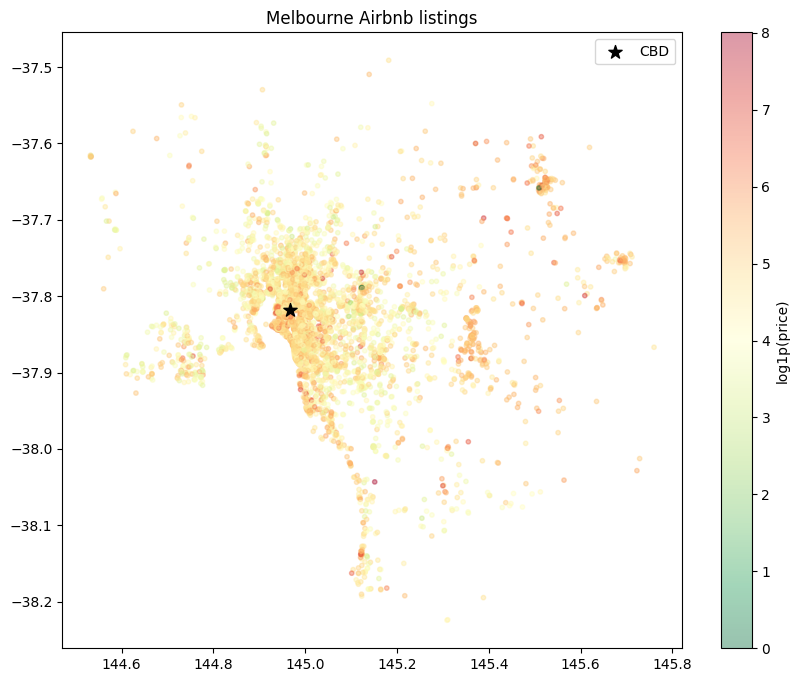

In [21]:
plt.figure(figsize=(10, 8))
sc = plt.scatter(df_tr['longitude'], df_tr['latitude'],
                 c=np.log1p(df_tr['price']), cmap='RdYlGn_r',
                 alpha=0.4, s=10)
plt.colorbar(sc, label='log1p(price)')
# Mark CBD
plt.scatter([144.9671], [-37.8183], c='black', s=100, marker='*', label='CBD')
plt.legend()
plt.title('Melbourne Airbnb listings')
plt.show()

#### Highly Correlated Pairs of Features

In [19]:
df_tr = df_tr.loc[:, df_tr.nunique() > 1]
df_tr.head()

,host_is_superhost,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,...,city_Nillumbik,city_Port Phillip,city_Stonnington,city_Whitehorse,city_Whittlesea,city_Wyndham,city_Yarra,city_Yarra Ranges,room_type_Private room,room_type_Shared room
0,0,-38.022565,145.098937,5,1.0,2.0,4.0,111,3,28,...,False,False,False,False,False,False,False,False,False,False
1,0,-37.782125,144.988079,3,1.0,1.0,1.0,80,1,59,...,False,False,False,False,False,False,True,False,False,False
2,1,-37.853710,144.981529,4,1.0,1.0,2.0,150,2,14,...,False,True,False,False,False,False,False,False,False,False
3,0,-37.876393,145.036635,2,1.0,1.0,1.0,125,1,39,...,False,False,False,False,False,False,False,False,False,False
4,0,-37.810398,144.950113,3,1.0,1.0,2.0,79,3,7,...,False,False,False,False,False,False,False,False,False,False


In [20]:
corr = df_tr.corr()
#corr_high = corr[(corr>0.8) & (corr<1.0)]

#### Feature Engineering

To attend to this problem, a **new feature** `dist_cbd` (distance from melbourne CBD) could be introduced to form a meaningful relationship between *location* and *price* instead.